In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
from data.data_loader import DataLoader  

In [29]:
num_clusters = 15
linkage_methods = ['complete', 'average', 'single', 'ward']
csv_path = "../data/processed/wind-farms.csv"  

df_points = pd.read_csv(csv_path)


df_operating = df_points[df_points["Development Status"] == "Operating"]
lon_col = 'Longitude'
lat_col = 'Latitude'

special_points = list(zip(df_operating[lon_col], df_operating[lat_col]))

In [19]:
print("Loading data...")
loader = DataLoader("../data/raw")
lsmdf, lsmc, rlsmcs5Wmnavg = loader.load_wind_correlation_data()
print("Data loaded")

Loading data...
Data loaded


In [66]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import numpy as np
import scipy.cluster.hierarchy as sch
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler

def compute_idxmap_spectral(lsmc, data, num_clusters=15):
    # Trova i pixel attivi
    active_idxs = np.flatnonzero(lsmc.flatten() == 1)

    # ⚠️ Qui va evitato di usare active_idxs per indicizzare 'data'
    # Perché 'data' è già stato costruito solo sui punti attivi!
    # Quindi non serve sotto-selezionarlo ancora!

    # Normalizza
    X_scaled = StandardScaler().fit_transform(data)

    # Applica Spectral Clustering
    sc = SpectralClustering(n_clusters=num_clusters, affinity='nearest_neighbors', random_state=42, n_neighbors=20)
    labels = sc.fit_predict(X_scaled)

    # Mappa i risultati
    idxmap = np.full(lsmc.size, np.nan)
    idxmap[active_idxs] = labels + 1  # +1 per evitare etichetta 0

    return idxmap.reshape(lsmc.shape)

def compute_idxmap(lsmc, data, method, num_clusters):
    distances = pairwise_distances(data)
    linkage_matrix = sch.linkage(squareform(distances.astype('float32')), method=method)
    labels = sch.fcluster(linkage_matrix, num_clusters, criterion='maxclust')
    idxmap = np.full(lsmc.size, np.nan)
    active_idxs = np.flatnonzero(lsmc.flatten() == 1)
    idxmap[active_idxs] = labels
    return idxmap.reshape(lsmc.shape)

def compute_idxmap_kmeans(lsmc, data, num_clusters):
    X_scaled = StandardScaler().fit_transform(data)
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    idxmap = np.full(lsmc.size, np.nan)
    active_idxs = np.flatnonzero(lsmc.flatten() == 1)
    idxmap[active_idxs] = labels + 1  # +1 per coerenza con fcluster
    return idxmap.reshape(lsmc.shape)


In [64]:
idxmap_dict = {}

for method in linkage_methods:
    print(f"Clustering con metodo {method}")
    idxmap_dict[method] = compute_idxmap(lsmc, rlsmcs5Wmnavg, method, num_clusters)

print("Clustering con KMeans")
idxmap_dict['kmeans'] = compute_idxmap_kmeans(lsmc, rlsmcs5Wmnavg, num_clusters)



Clustering con metodo complete
Clustering con metodo average
Clustering con metodo single
Clustering con metodo ward
Clustering con KMeans


In [67]:
print("Clustering con Spectral")
idxmap_dict['spectral'] = compute_idxmap_spectral(lsmc, rlsmcs5Wmnavg, num_clusters=15)

Clustering con Spectral


C:\Users\bizza\Desktop\XGeoAI\venv\Lib\site-packages\sklearn\cluster\_spectral.py:703: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(


In [68]:
def plot_clusters_with_points(lsmdf, idxmap_dict, special_points, num_clusters=15):
    n = len(idxmap_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, (method, idxmap) in zip(axes, idxmap_dict.items()):
        im = ax.pcolor(lsmdf.longitude, lsmdf.latitude, idxmap, cmap='tab20',
                       vmin=0.5, vmax=num_clusters + 0.5)

        # Titolo del metodo
        ax.set_title(f"Method: {method}")

        # Nasconde assi, ticks, etichette
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        # Punti speciali neri e piccoli
        if special_points:
            lons, lats = zip(*special_points)
            ax.scatter(lons, lats, color='black', s=10, marker='o')

    # Rimuove la colorbar (legenda dei cluster)
    # Se proprio vuoi rimuovere del tutto:
    #    → commenta o rimuovi la riga sotto
    # fig.colorbar(im, ax=axes, shrink=0.7, label="Cluster ID")

    # Titolo complessivo
    fig.suptitle(f"Clustering (n={num_clusters}) con punti speciali", fontsize=16)

    plt.show()

    


In [69]:
def summarize_special_points_distribution(lsmdf, idxmap_dict, special_points, top_n=5):
    """
    Per ogni metodo di clustering:
    - Conta quanti dei punti speciali finiscono nei cluster
    - Mostra quanti cluster diversi li contengono
    - Mostra la percentuale cumulativa dei top N cluster (per numero di punti)
    """
    from collections import Counter

    print("Classifica dei cluster per densità di punti speciali:\n")

    for method, idxmap in idxmap_dict.items():
        cluster_ids = []

        for lon, lat in special_points:
            # Trova gli indici più vicini nella griglia
            x_idx = (np.abs(lsmdf.longitude - lon)).argmin()
            y_idx = (np.abs(lsmdf.latitude - lat)).argmin()

            cluster_id = idxmap[y_idx, x_idx]
            if not np.isnan(cluster_id):
                cluster_ids.append(int(cluster_id))

        total_points = len(special_points)
        valid_points = len(cluster_ids)
        unique_clusters = len(set(cluster_ids))
        cluster_counts = Counter(cluster_ids)
        sorted_counts = sorted(cluster_counts.values(), reverse=True)

        # Cumulativa percentuale dei top N cluster
        top_counts = sorted_counts[:top_n]
        cumulative = sum(top_counts)
        cumulative_percent = 100 * cumulative / valid_points if valid_points > 0 else 0

        print(f"Metodo: {method}")
        print(f"   - Punti totali: {total_points}")
        print(f"   - Punti validi (in cluster): {valid_points}")
        print(f"   - Distribuiti su {unique_clusters} cluster diversi")
        print(f"   - Top {top_n} cluster contengono il {cumulative_percent:.1f}% dei punti")
        print("")


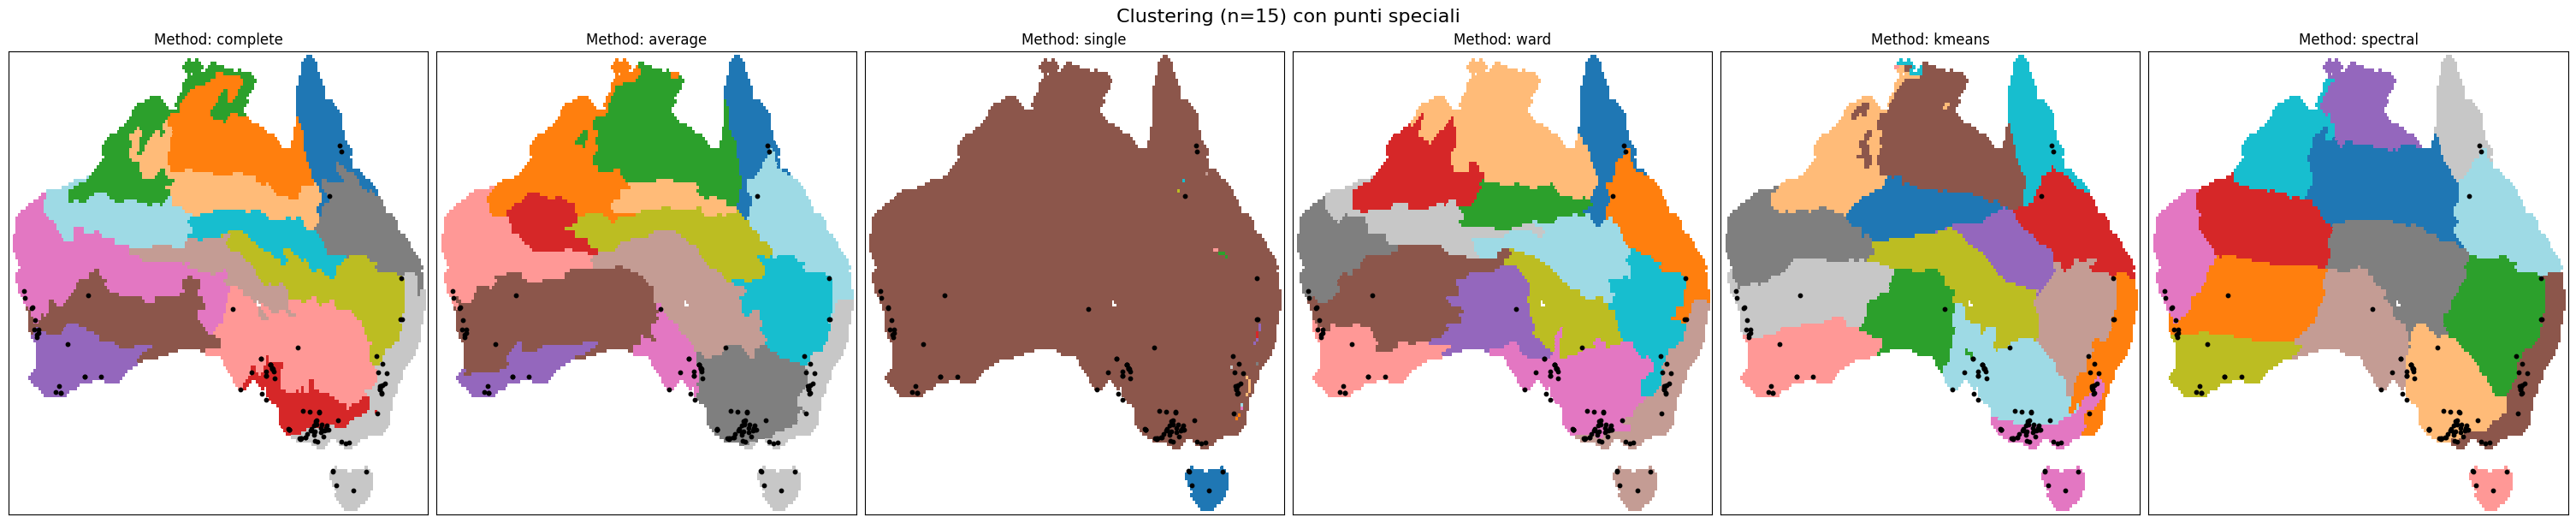

In [70]:
plot_clusters_with_points(lsmdf, idxmap_dict, special_points, num_clusters)

In [71]:
summarize_special_points_distribution(lsmdf, idxmap_dict, special_points, top_n=3)

Classifica dei cluster per densità di punti speciali:

Metodo: complete
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 9 cluster diversi
   - Top 3 cluster contengono il 81.6% dei punti

Metodo: average
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 10 cluster diversi
   - Top 3 cluster contengono il 75.7% dei punti

Metodo: single
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 2 cluster diversi
   - Top 3 cluster contengono il 100.0% dei punti

Metodo: ward
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 10 cluster diversi
   - Top 3 cluster contengono il 81.6% dei punti

Metodo: kmeans
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 9 cluster diversi
   - Top 3 cluster contengono il 74.8% dei punti

Metodo: spectral
   - Punti totali: 105
   - Punti validi (in cluster): 103
   - Distribuiti su 10 cluster diversi
   - Top 3 clust